In [1]:
from pathlib import Path
import json
from collections import Counter

import pandas as pd
from IPython.display import Image, display

import tpa_figures as tpa

fig_dir = Path("reproduced_figures")
fig_dir.mkdir(exist_ok=True)

tpa.setup_style()

In [2]:
with open("TPAML.json", encoding="utf-8") as f:
    molecules = json.load(f)

features = pd.read_csv("TPAML_Features_696.csv")

print(f"{len(molecules)} chromophores in the raw dataset")
print(f"feature matrix: {features.shape[0]} molecules x {features.shape[1] - 1} features")

929 chromophores in the raw dataset
feature matrix: 856 molecules x 696 features


In [3]:
bands_per_molecule = [len(m["wavelength"]) if isinstance(m["wavelength"], list) else 1
                      for m in molecules]
single = sum(n == 1 for n in bands_per_molecule)
print(f"single wavelength: {single}   multiple wavelengths: {len(molecules) - single}")

solvents = Counter(tpa.canon_solvent(m.get("Solvent")) for m in molecules)
print(f"{len(solvents)} solvents; five most common: {solvents.most_common(5)}")

single wavelength: 433   multiple wavelengths: 496
21 solvents; five most common: [('Toluene', 273), ('THF', 149), ('DCM', 133), ('TCM', 120), ('DMF', 84)]


In [4]:
notes = []
tpa.draw_figure_1(molecules, features, notes)

In [5]:
tpa.draw_figure_s3(features)
tpa.draw_figure_s7(features, notes)
tpa.draw_figure_s8(features, notes)
tpa.draw_figure_s15g(features, notes)

# keep the data-source notes alongside the figures
(fig_dir / "notes.txt").write_text("\n".join(notes) + "\n", encoding="utf-8")

e:\miniconda3\envs\AI4chem\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
e:\miniconda3\envs\AI4chem\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
e:\miniconda3\envs\AI4chem\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


4425

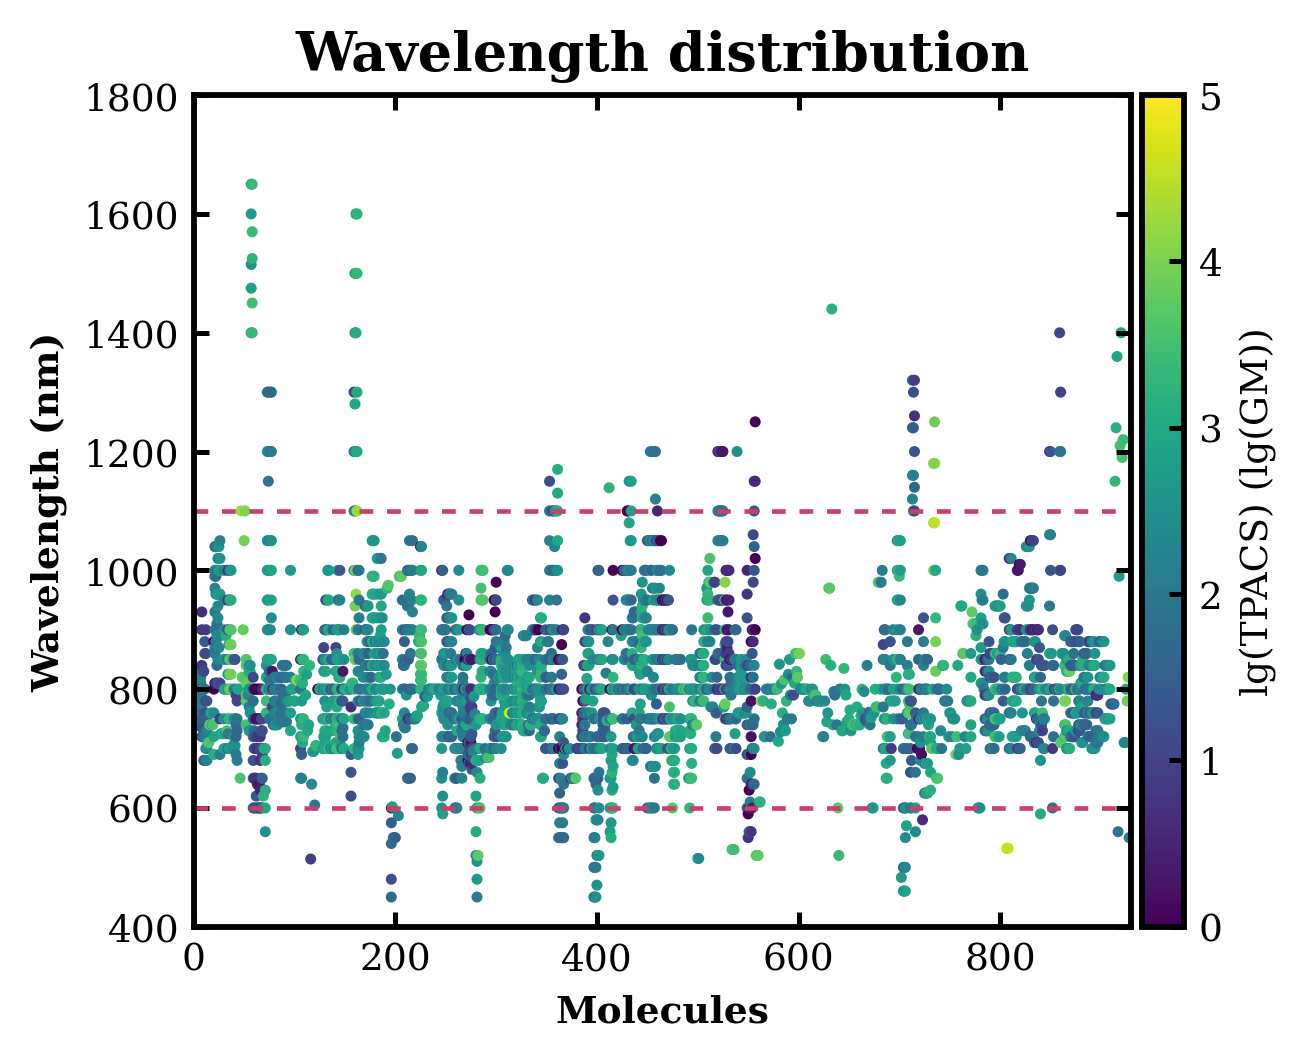

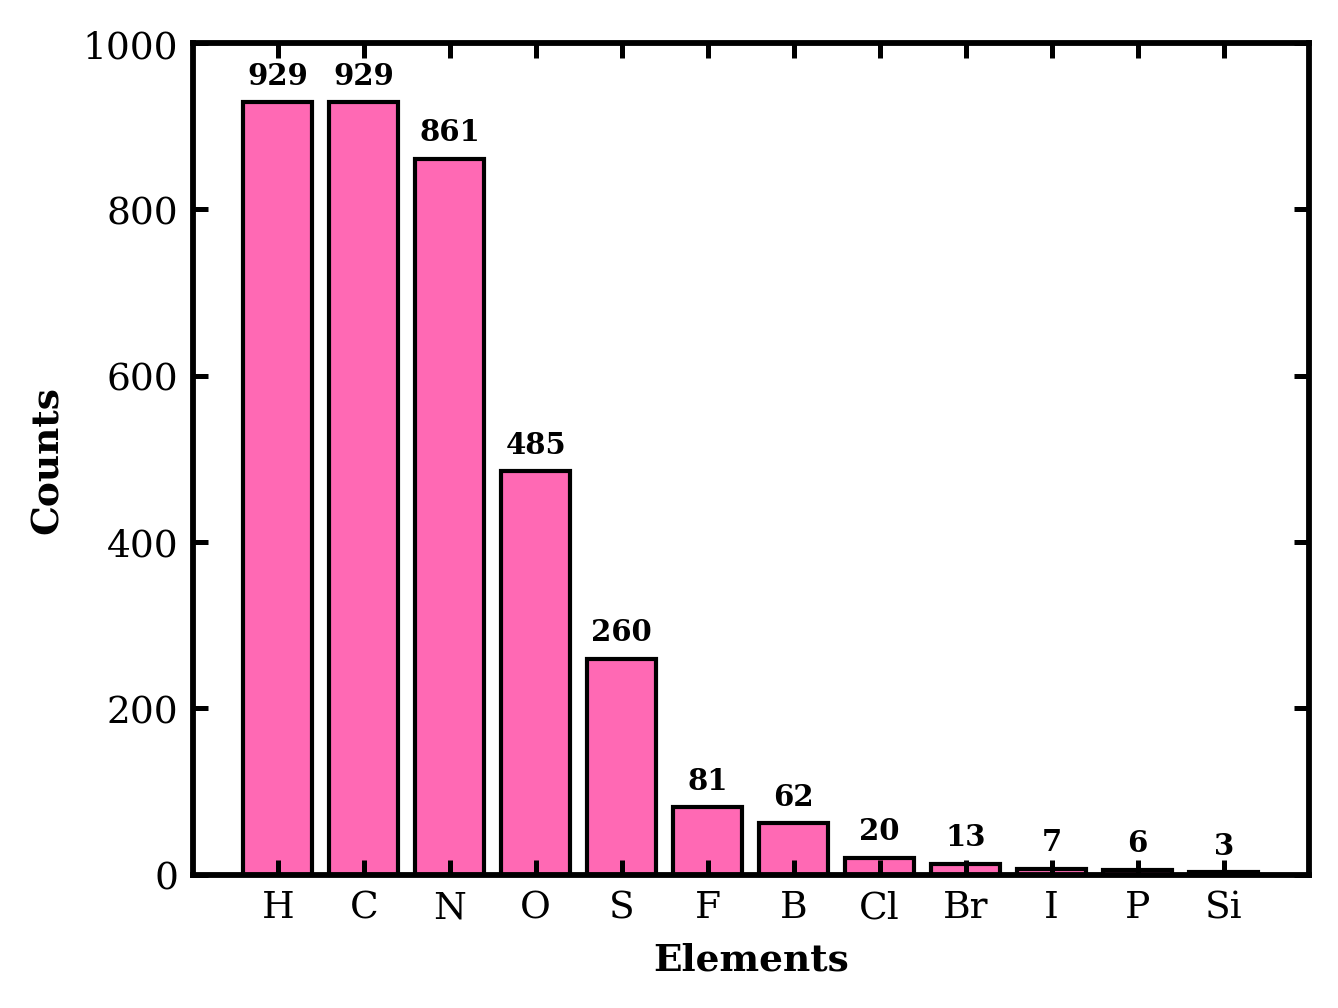

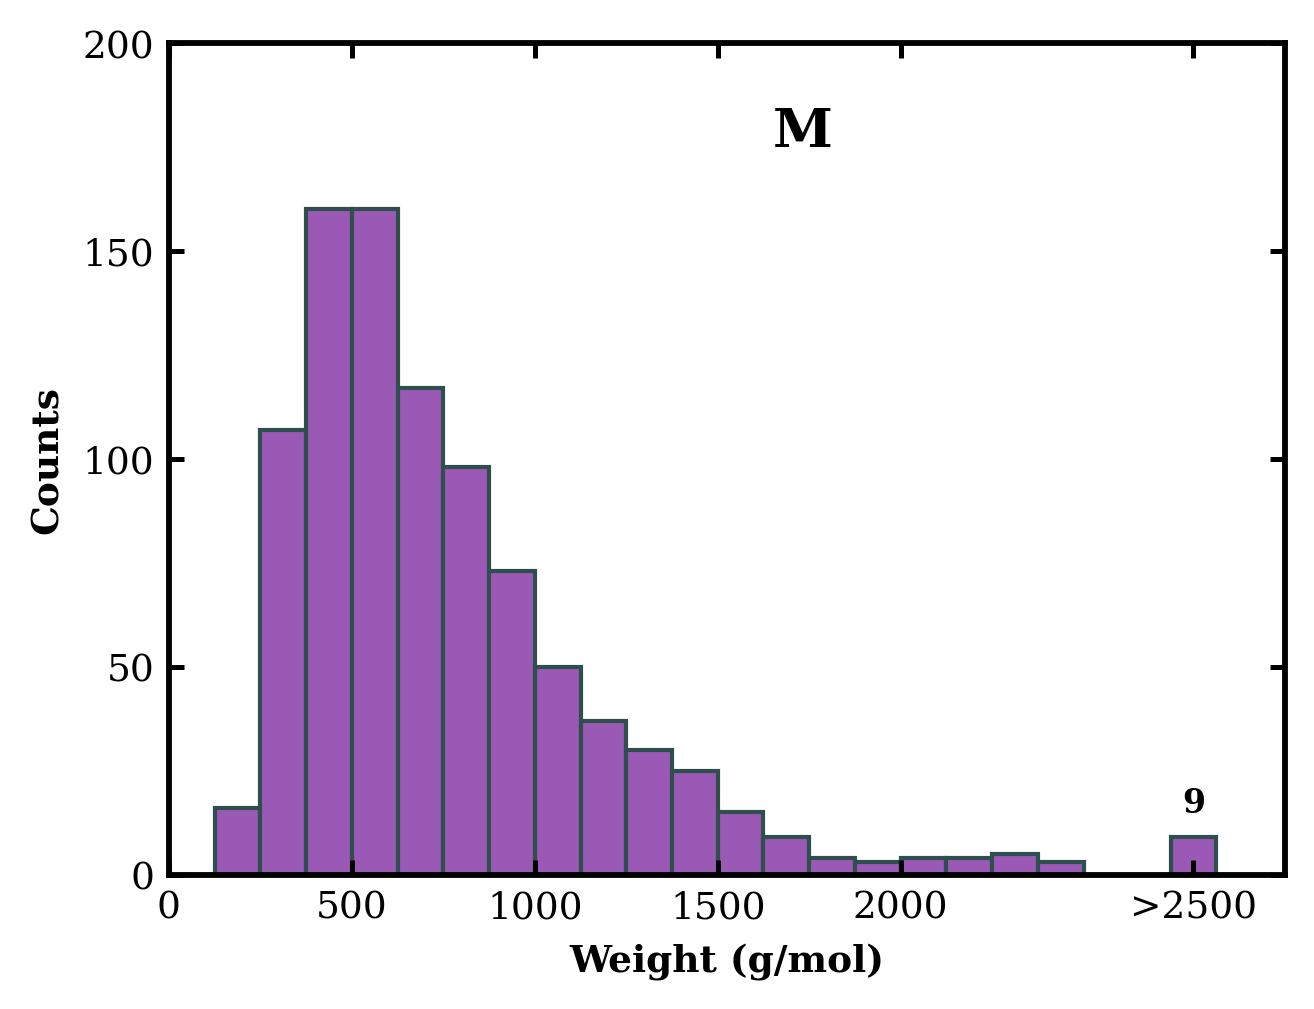

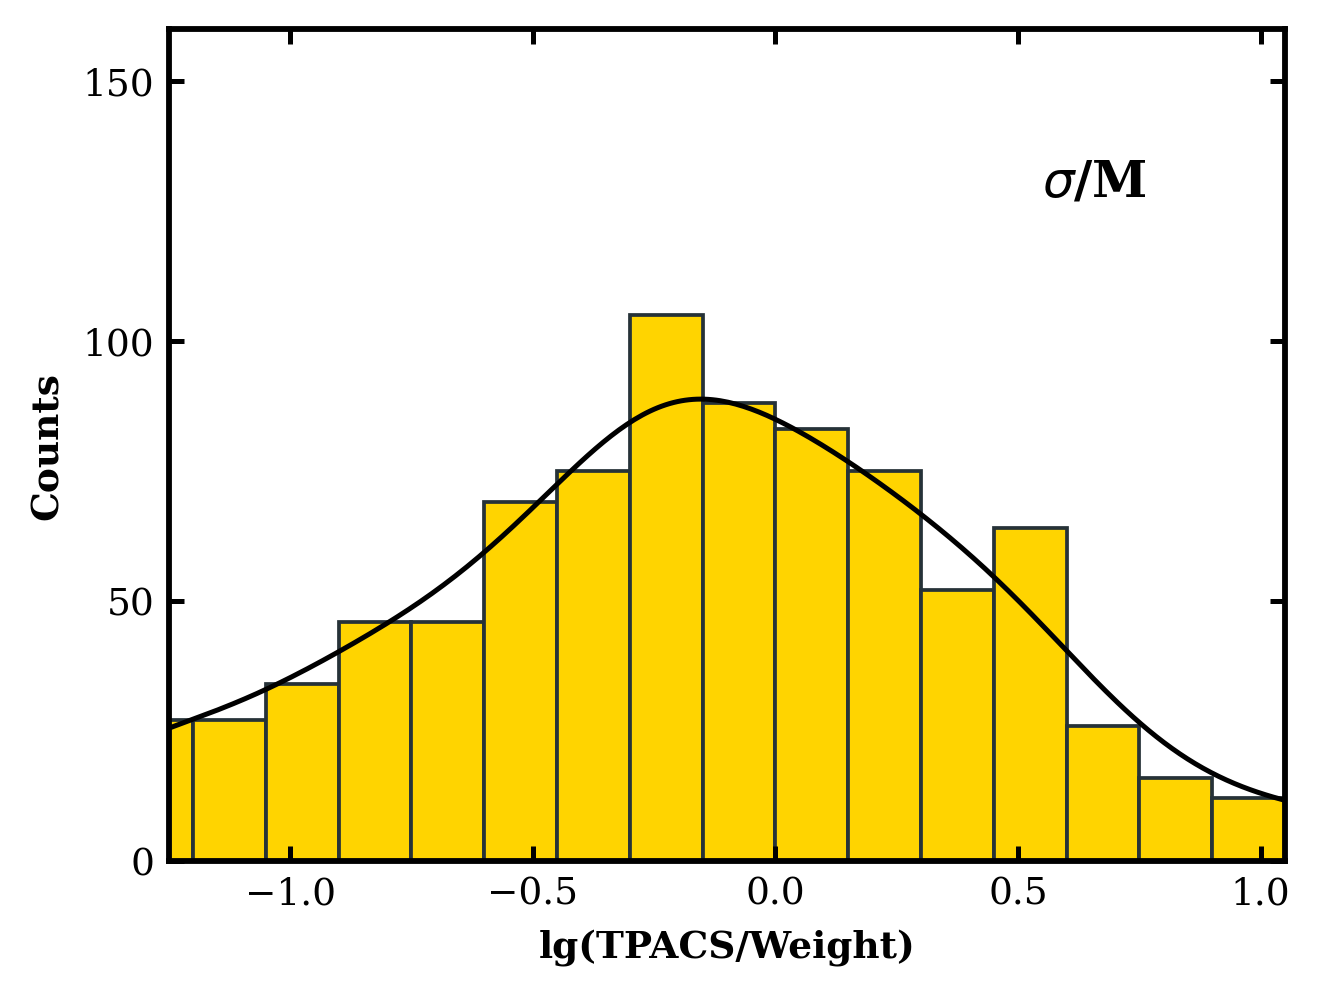

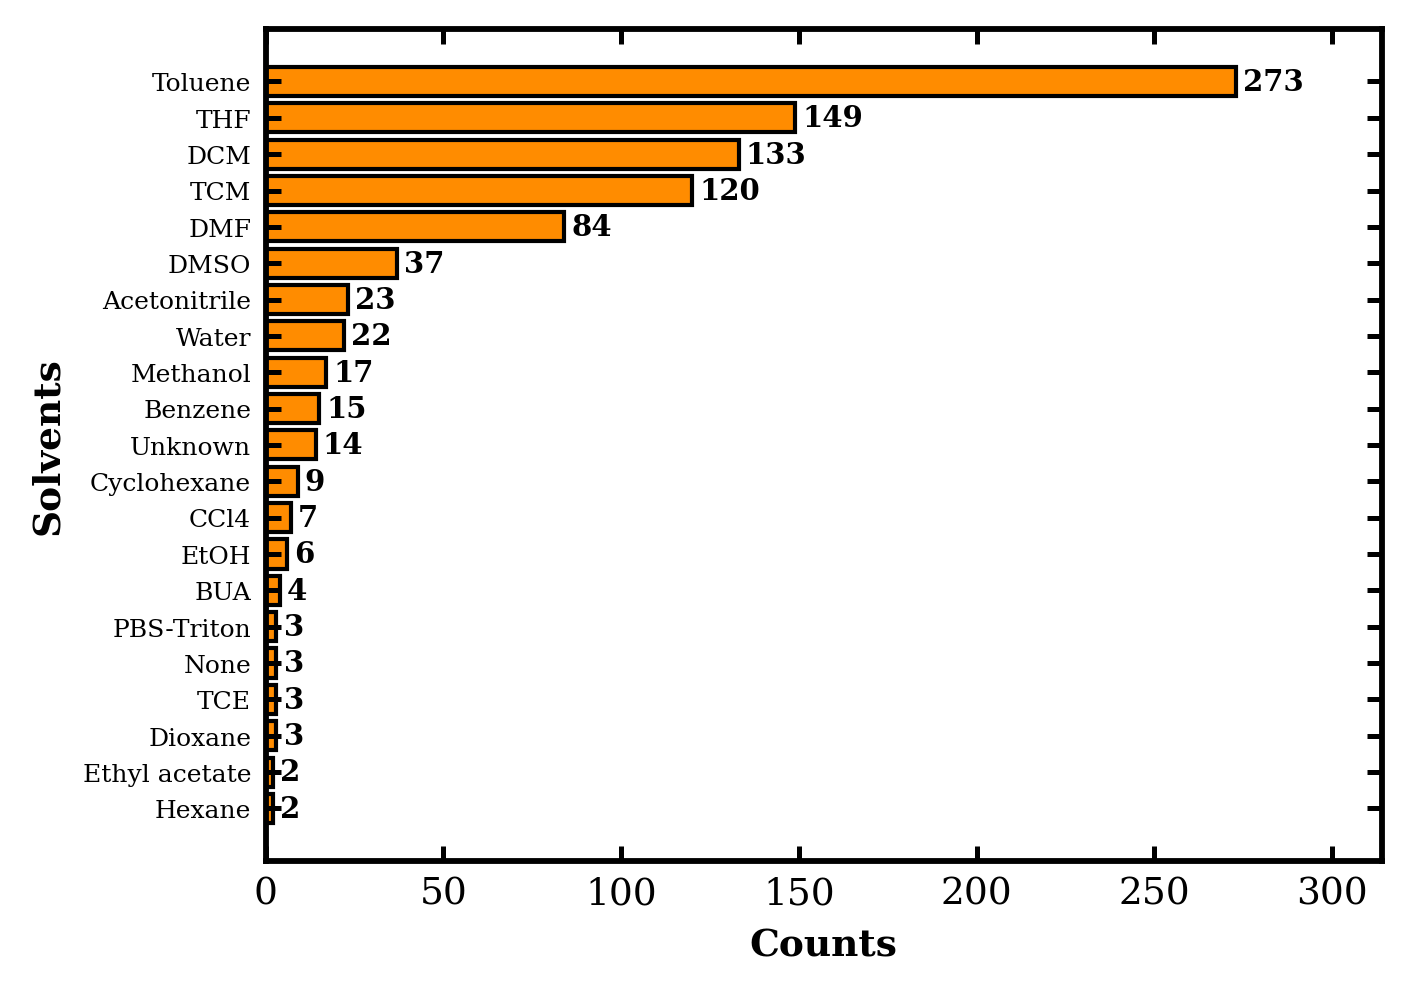

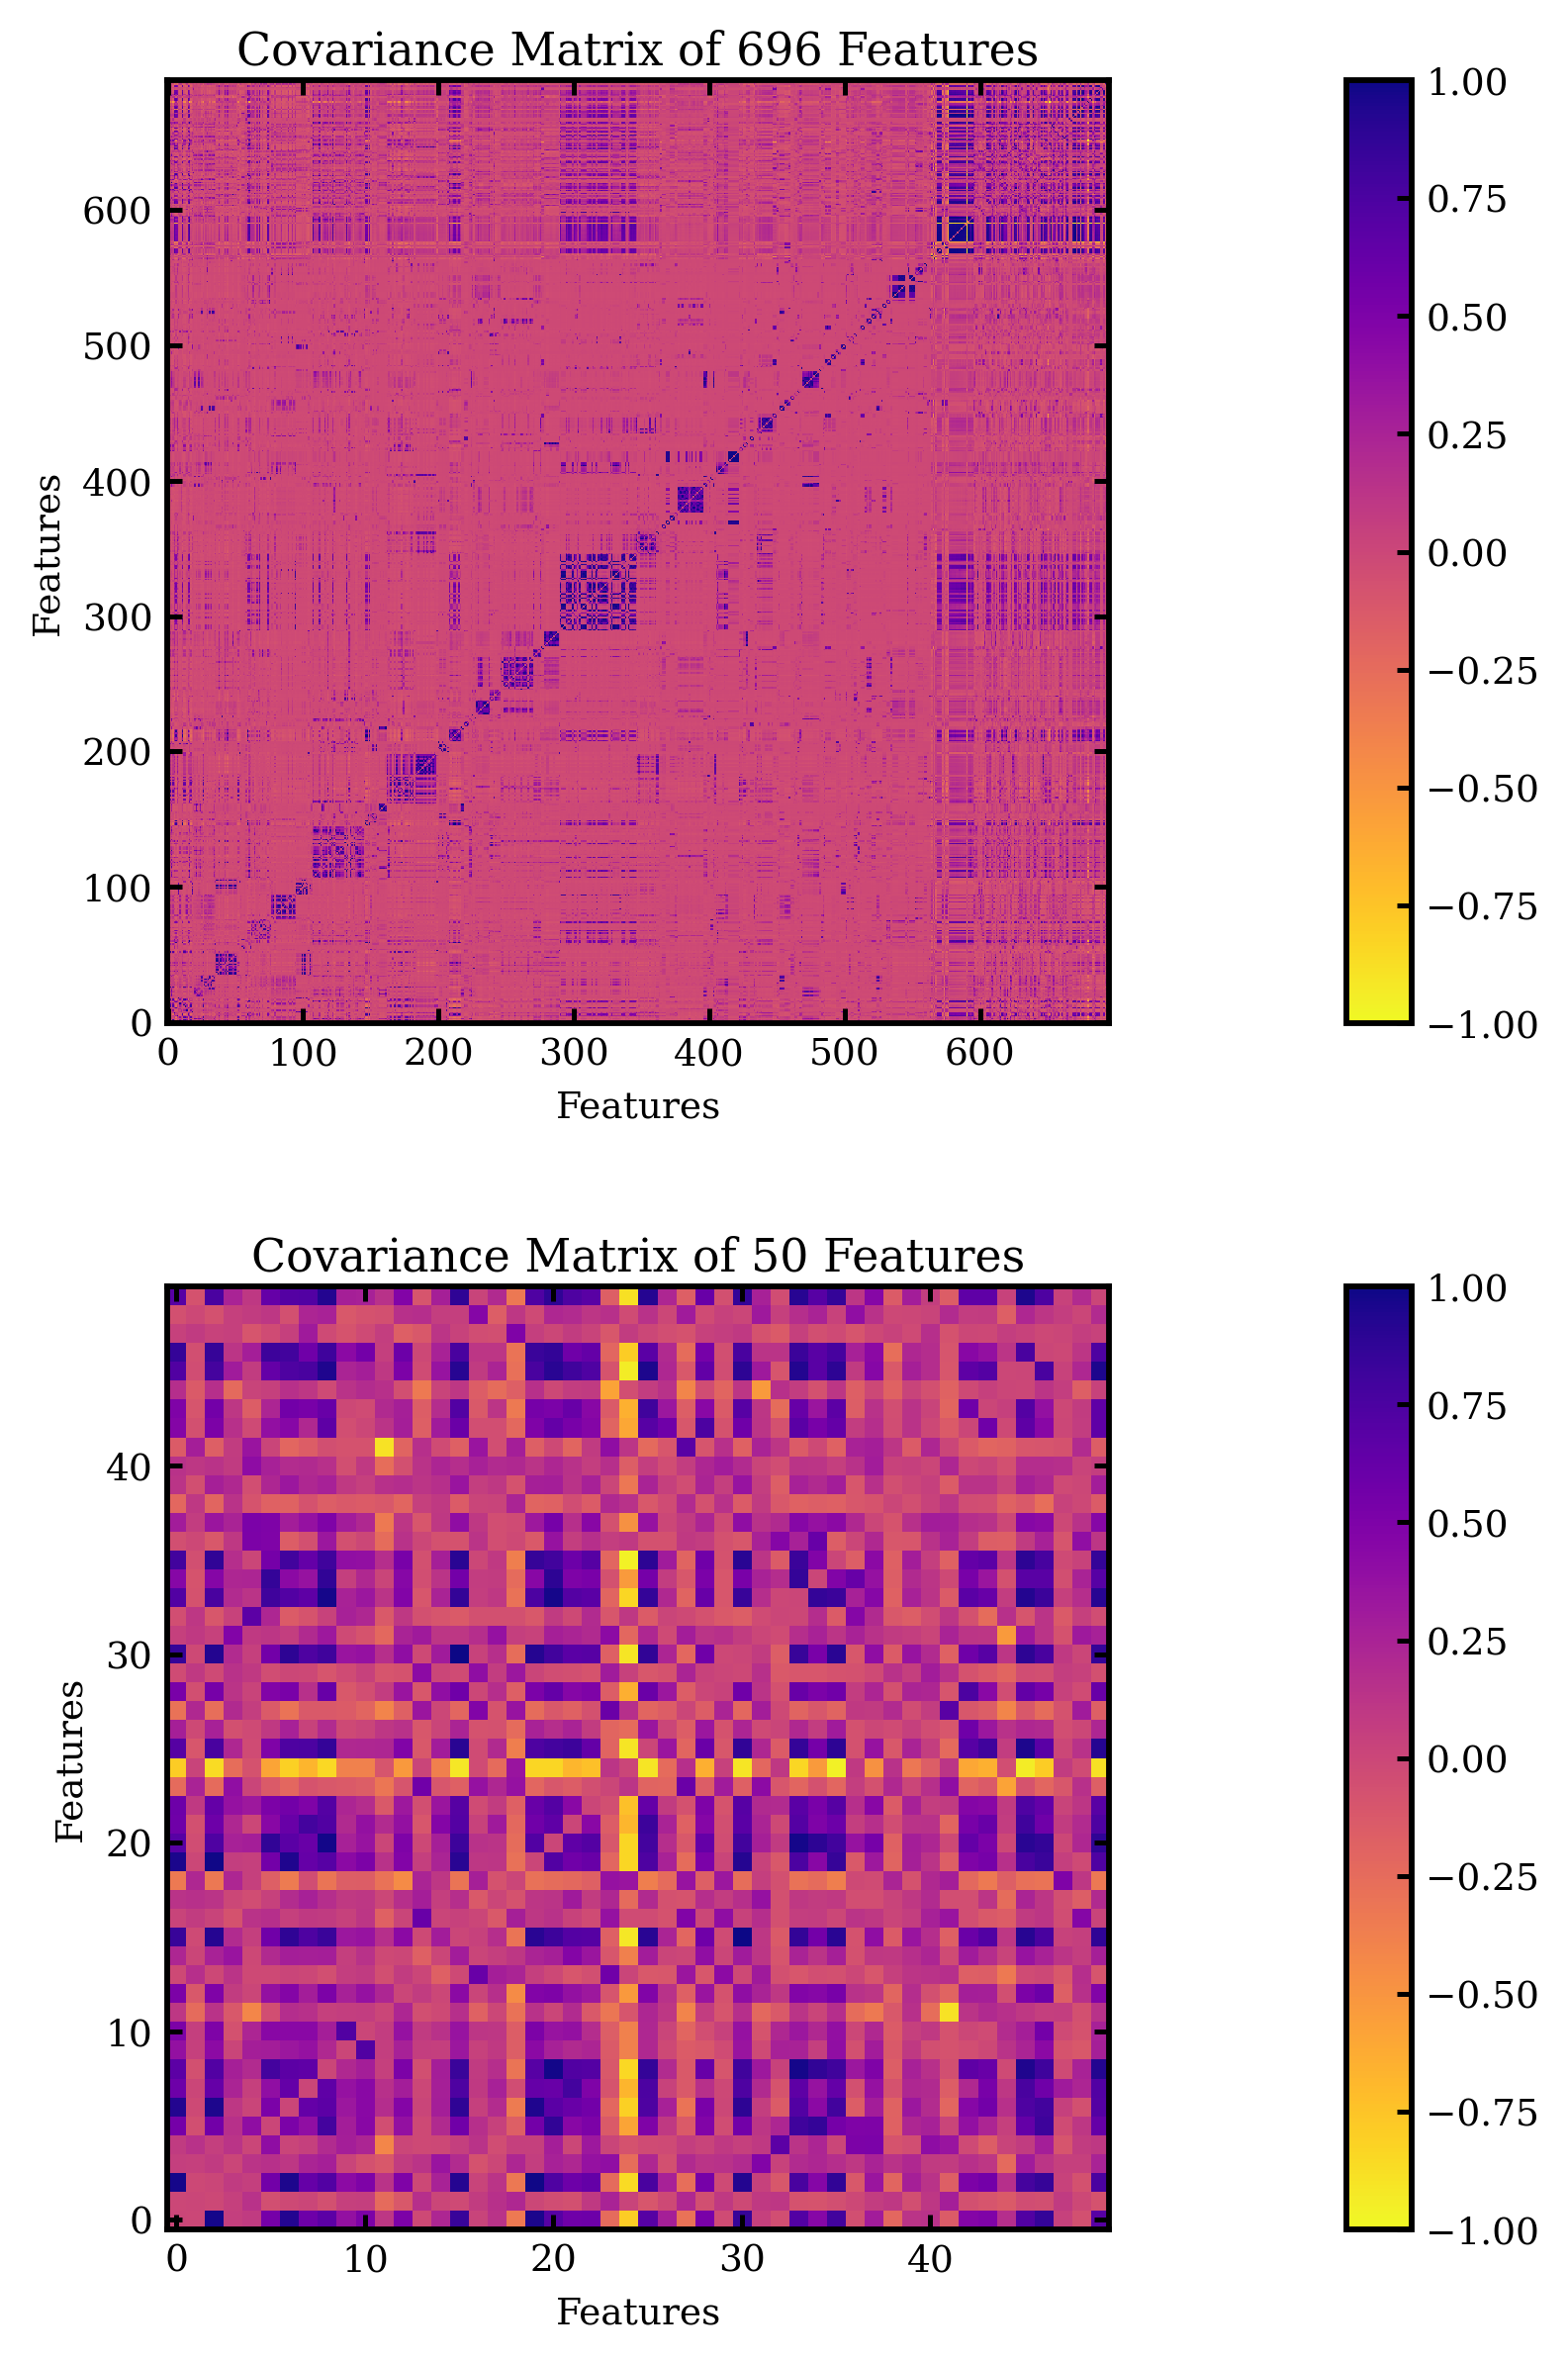

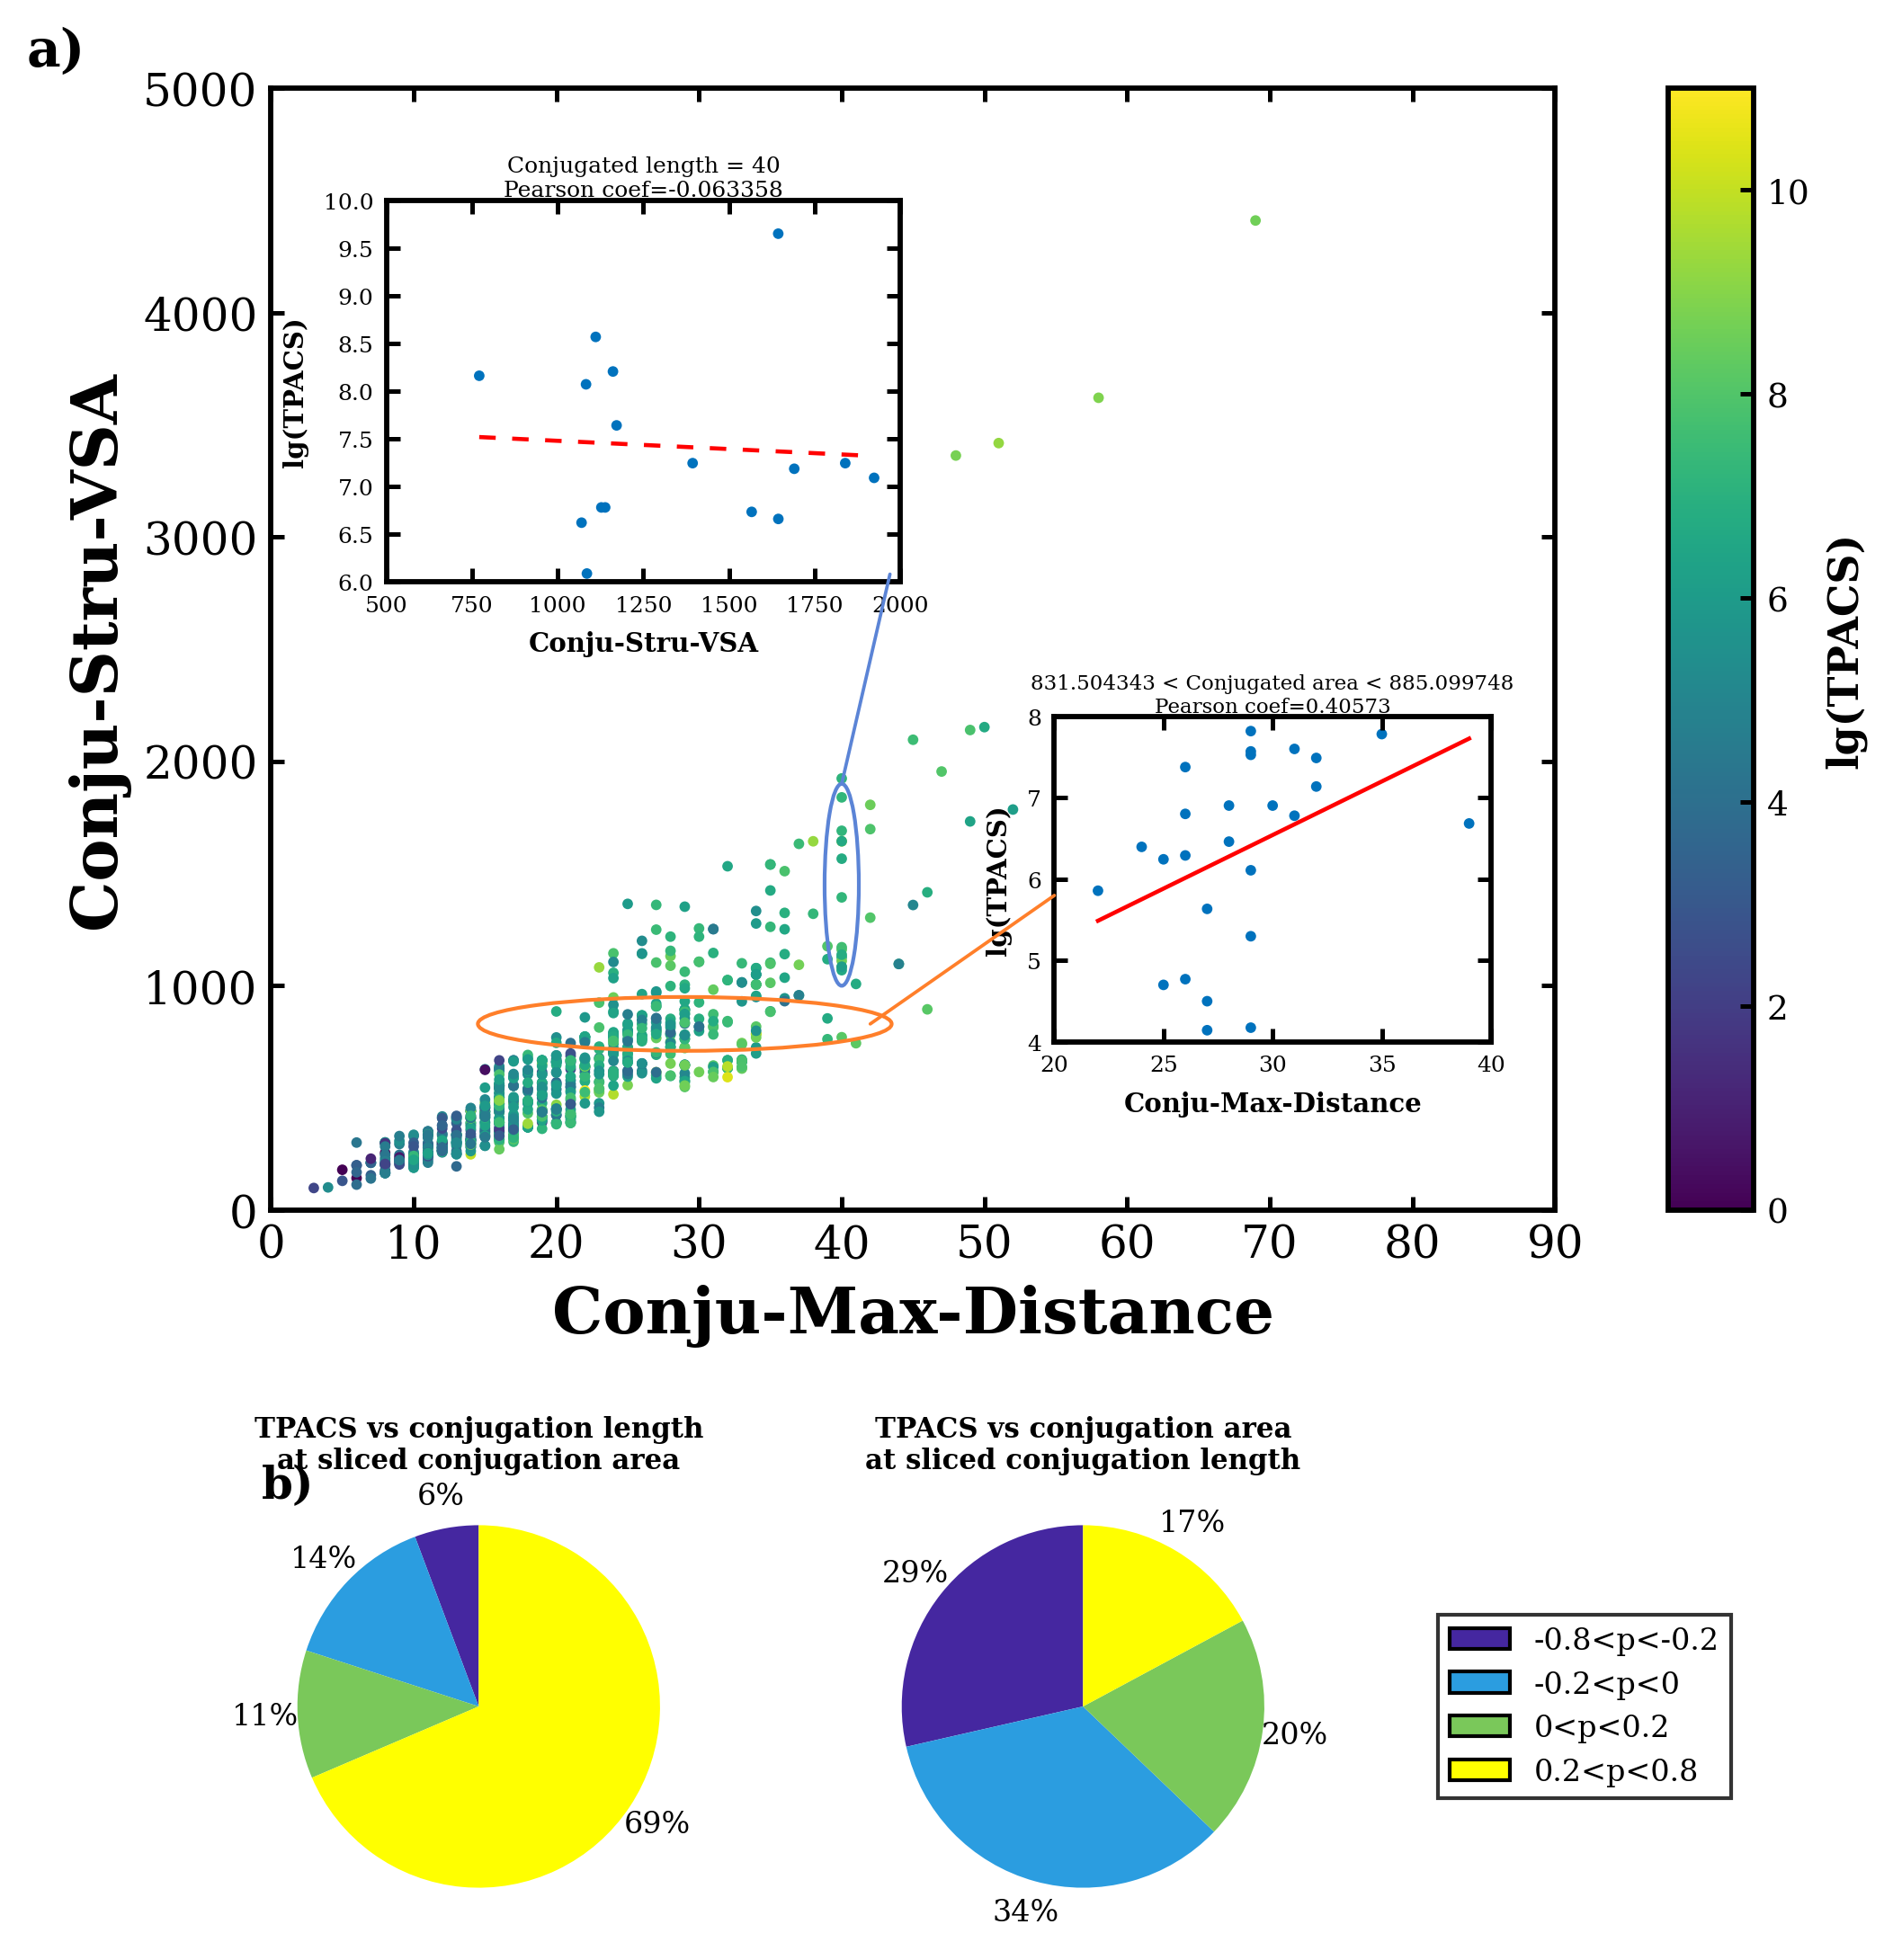

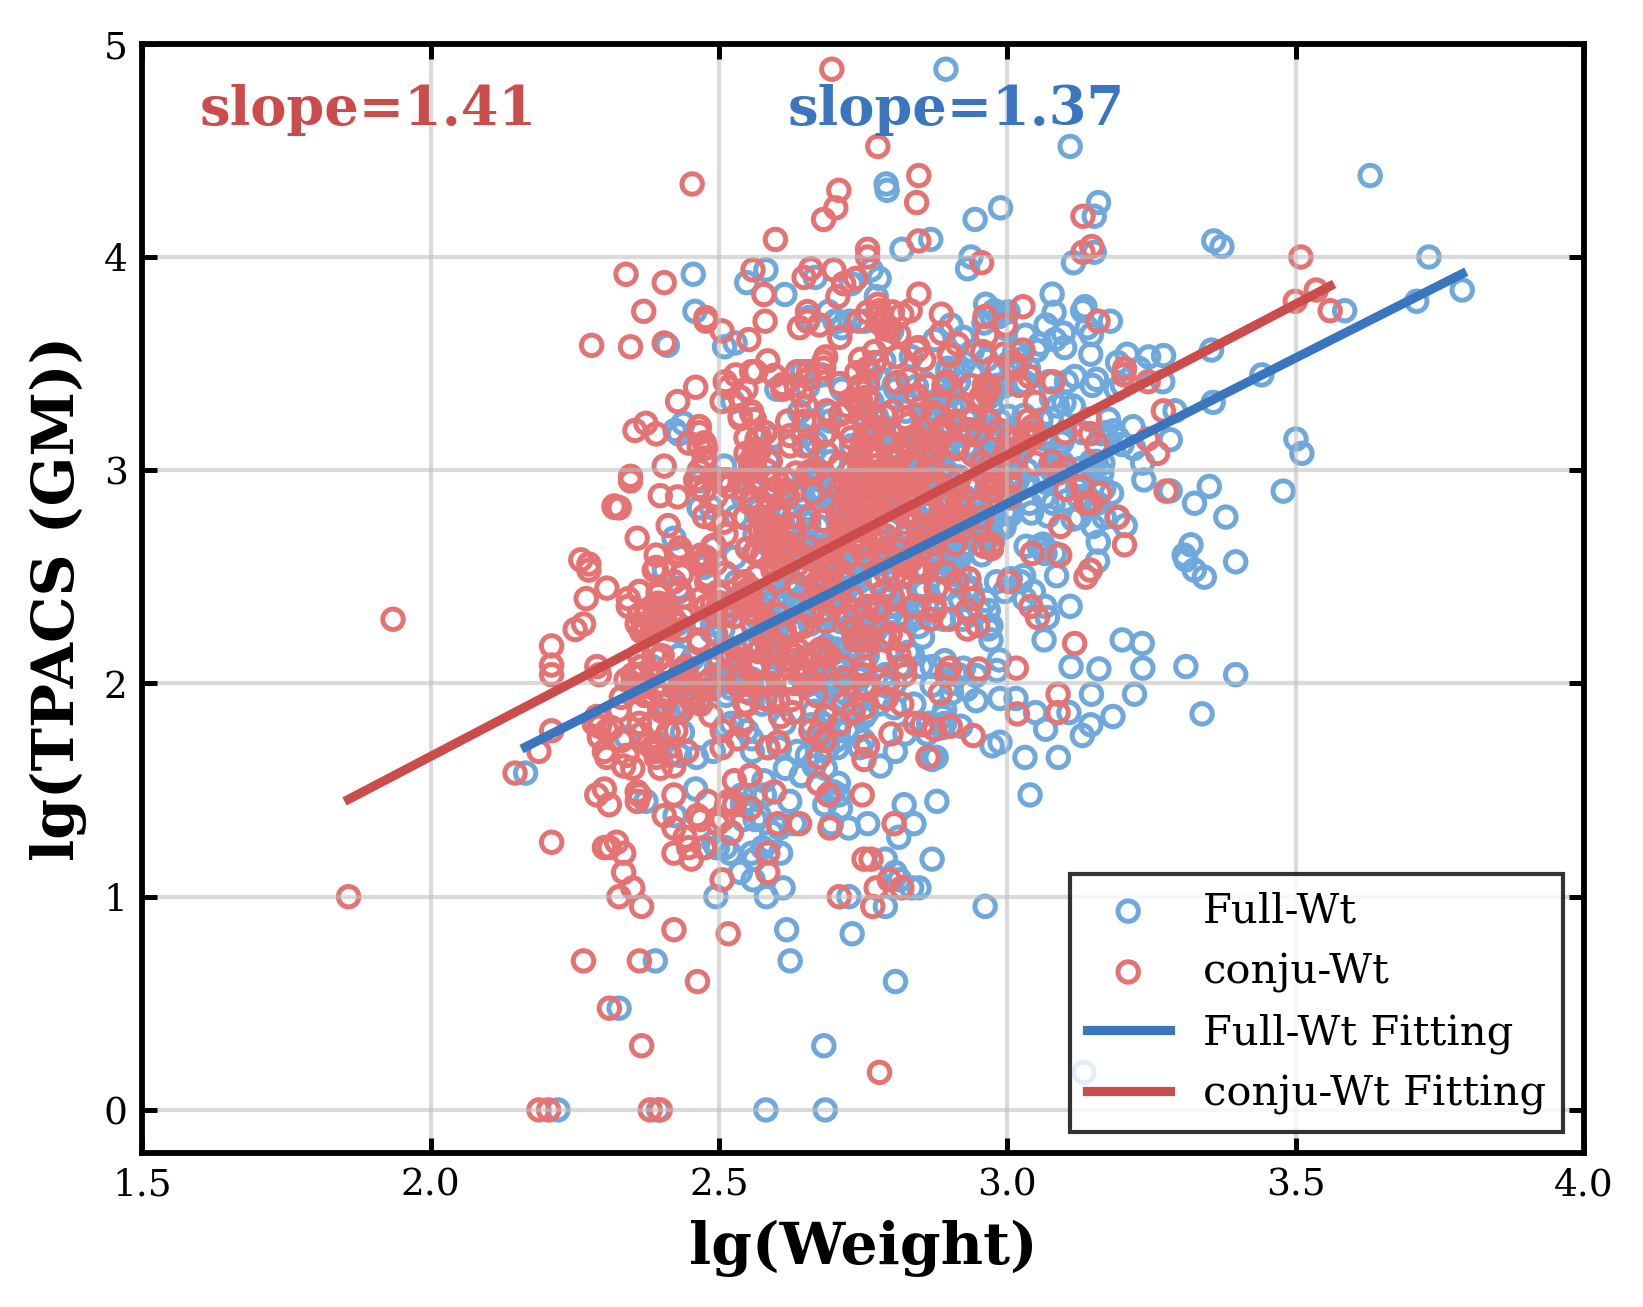

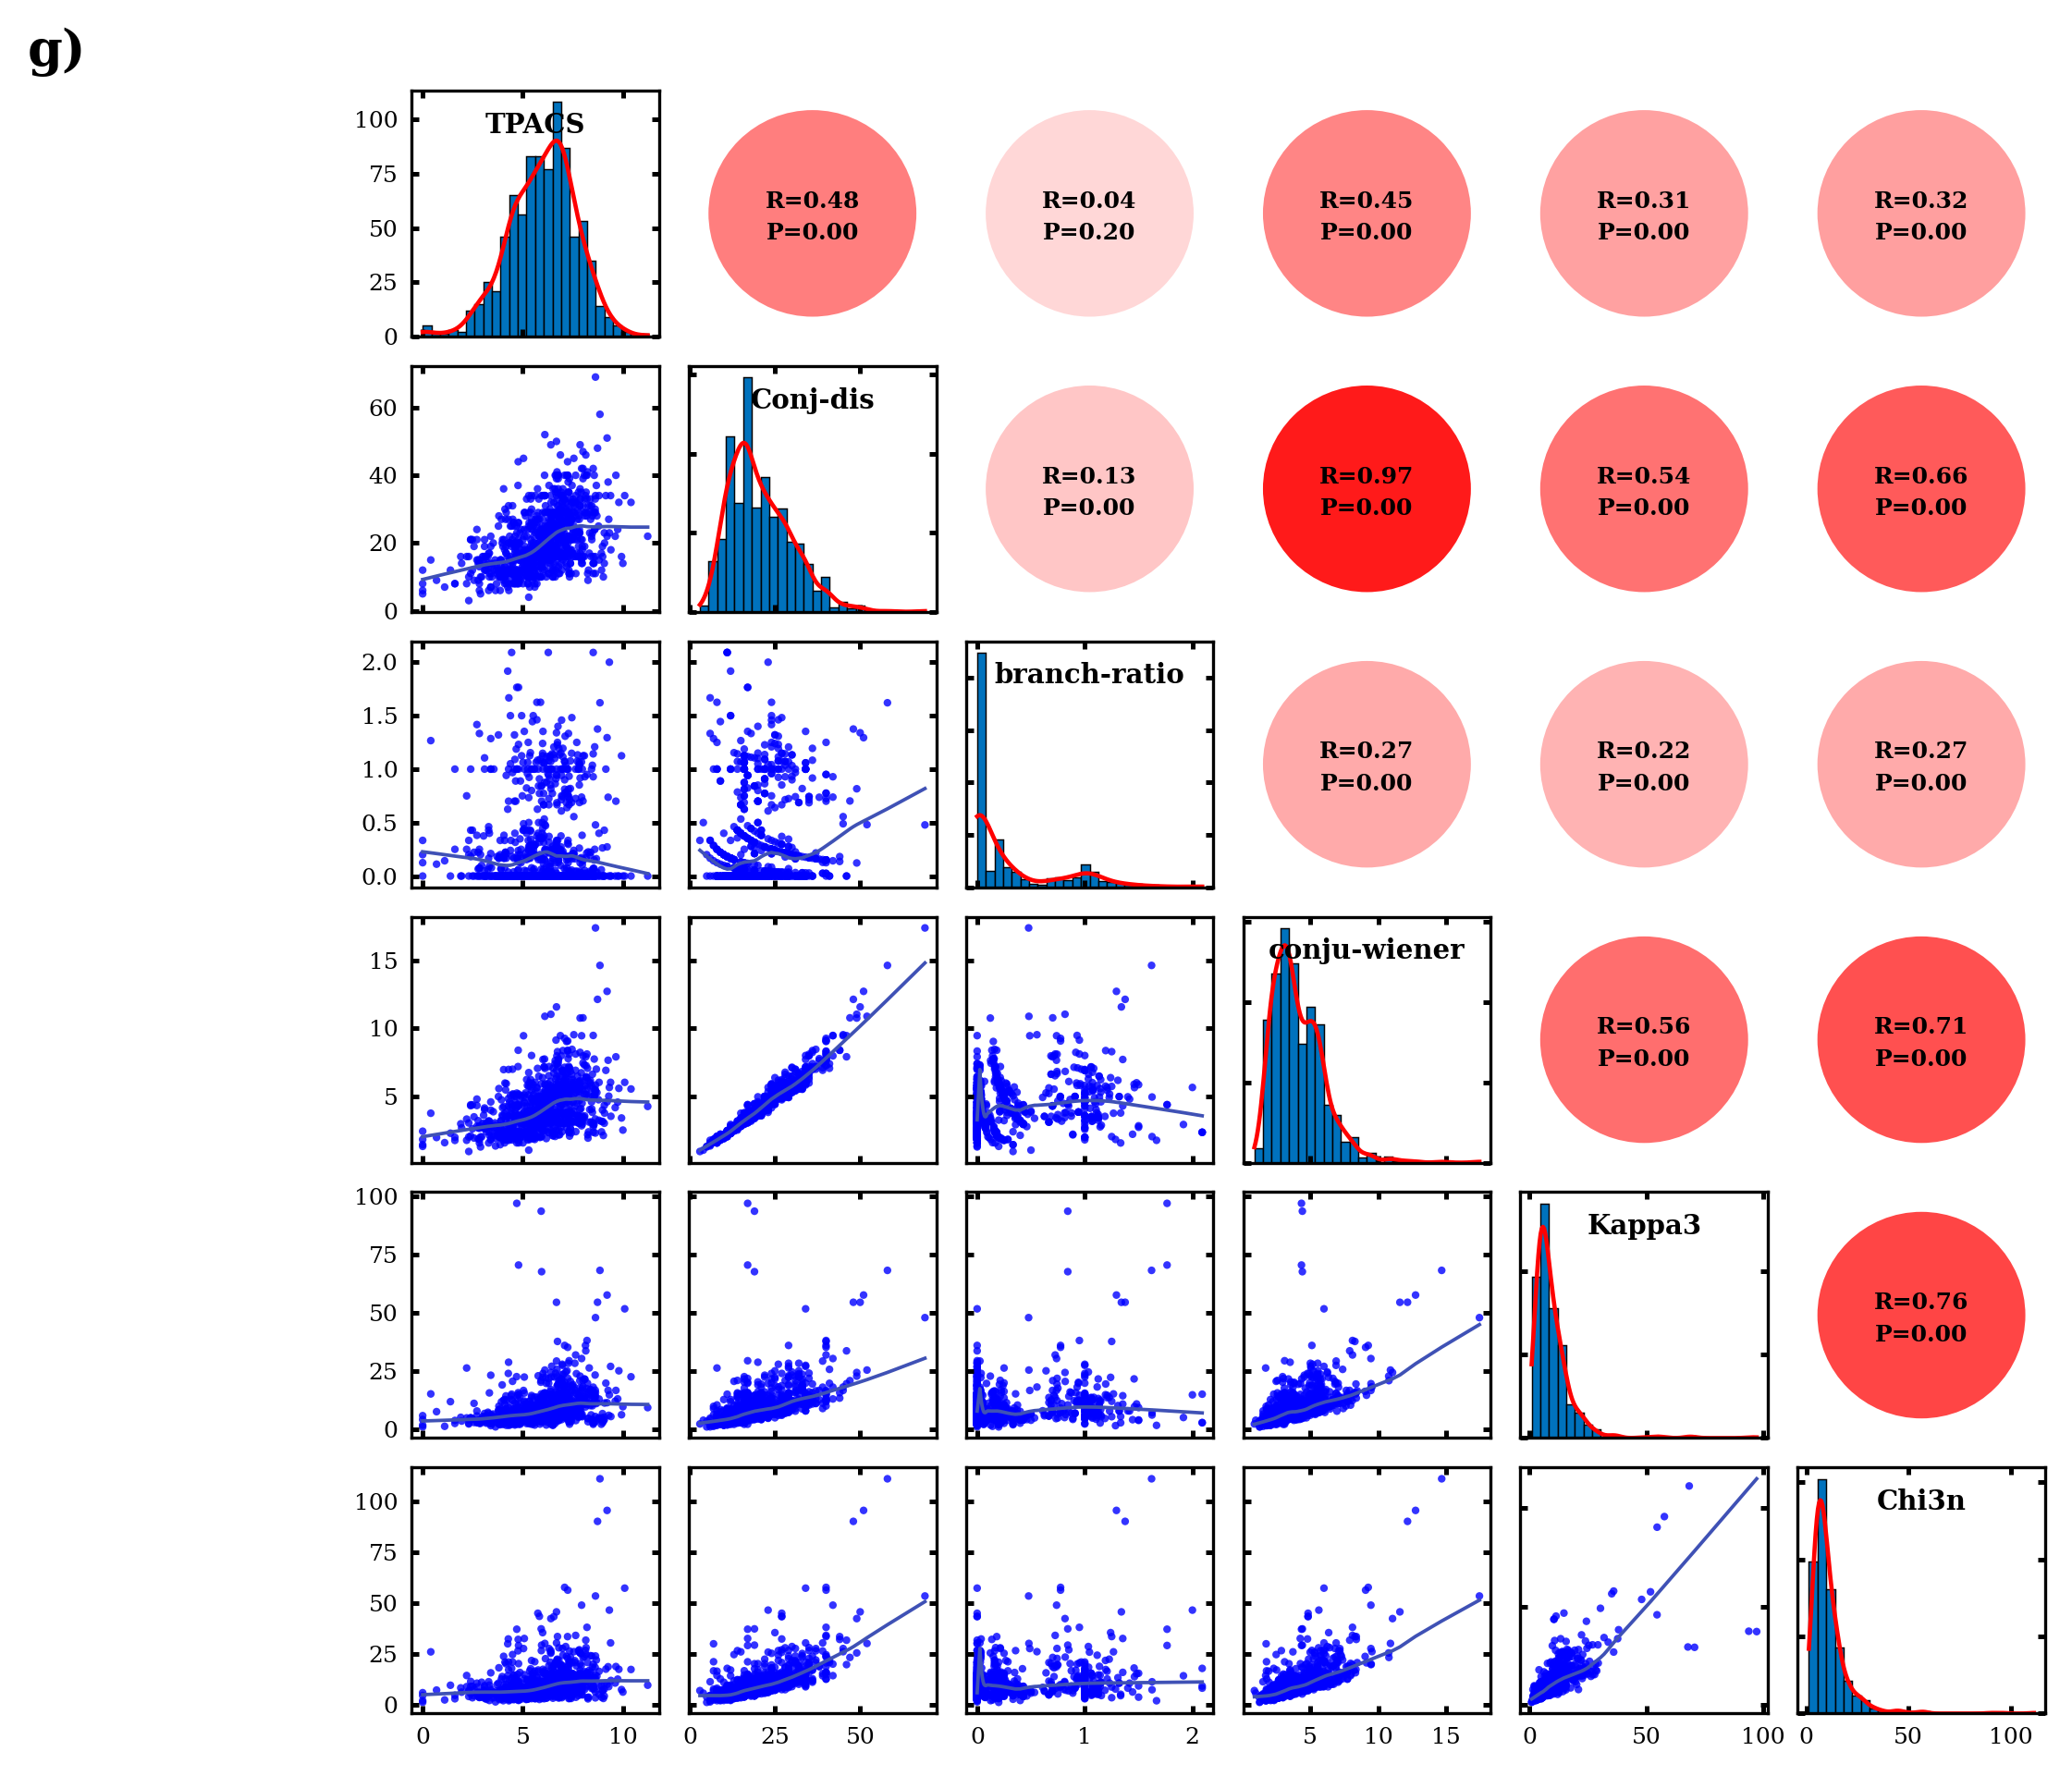

In [6]:
panels = ["Figure_1a", "Figure_1b", "Figure_1c", "Figure_1d", "Figure_1e",
          "Figure_S3", "Figure_S7", "Figure_S8", "Figure_S15g"]
for name in panels:
    display(Image(fig_dir / f"{name}.png"))